<a href="https://colab.research.google.com/github/ramvrum/dap-2024/blob/main/les07/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №7. Классификация

Используя набор данных titanic.csv постройте модель предсказывающую выжил или погиб пассажир.
1.	PassengerId – Идентификатор пассажира (уникальный номер для каждого пассажира).
2.	Survived – Выжил (0 – не выжил, 1 – выжил).
3.	Pclass – Класс пассажира (1 – первый класс, 2 – второй класс, 3 – третий класс).
4.	Name – Имя (полное имя пассажира).
5.	Sex – Пол (male – мужчина, female – женщина).
6.	Age – Возраст (числовое значение, может быть дробным).
7.	SibSp – Количество родственников на борту (братьев, сестер или супругов).
8.	Parch – Количество родителей или детей на борту.
9.	Ticket – Номер билета.
10.	Fare – Стоимость билета (в фунтах стерлингов).
11.	Cabin – Номер каюты (может быть пропущен, если данные отсутствуют).
12.	Embarked – Порт посадки (C – Cherbourg, Q – Queenstown, S – Southampton).

In [2]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0


## Извлечение данных

1. Создайте DataFarame из файла titanic.csv, в качестве индекса используйте столбец "PassengerId".

In [41]:
link = "https://raw.githubusercontent.com/ramvrum/dap-2024/main/les07/data/titanic.csv"
df = pd.read_csv(link, index_col="PassengerId")

df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


2. Выведете первые 7 строк набора.

In [42]:
df.head(7)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


### Подготовка данных

3. Выведете информацию о типах данных в наборе. Имеются ли в наборе не числовые признаки? Имеются ли в наборе данные имеющие значение null?
    

In [43]:
print("Типы данных:")
print(df.dtypes)

print("\nКатегориальные признаки:")
print(df.select_dtypes(include="object").columns)

print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())

Типы данных:
Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

Категориальные признаки:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

Количество пропусков в каждом столбце:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


4. Удалите не числовые признаки, которые по вашему мнению, не могут влиять на заначение выжил или погиб пассажир.

In [44]:
df = df.drop(columns=["Name", "Ticket", "Cabin"])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S
888,1,1,female,19.0,0,0,30.0000,S
889,0,3,female,NaN,1,2,23.4500,S


5. Вместо признака "Sex" (я надеюсь вы его не удалили 😂) Создайте два новых признака male и female которые содержат значения 0 или 1.

In [45]:
df = pd.concat([df, pd.get_dummies(df['Sex'])], axis=1)
df[['male', 'female']] = df[['male', 'female']].astype(int)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,female,male
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,0,1
2,1,1,female,38.0,1,0,71.2833,C,1,0
3,1,3,female,26.0,0,0,7.9250,S,1,0
4,1,1,female,35.0,1,0,53.1000,S,1,0
5,0,3,male,35.0,0,0,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S,0,1
888,1,1,female,19.0,0,0,30.0000,S,1,0
889,0,3,female,NaN,1,2,23.4500,S,1,0


6. Удалите строки, которые содержать хотя бы одно null значение.

In [46]:
df = df.dropna()
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
female      0
male        0
dtype: int64


## Исследование данных

4. Нормализуйте значения признака "Fare".

In [48]:
from sklearn.preprocessing import StandardScaler
titanic_df_fare = df[['Fare']]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(titanic_df_fare)

titanic_df_fare = pd.DataFrame(scaled_data, columns=["Fare"], index=df.index)

df = df[['Survived','Pclass','SibSp','Parch','female','male', 'Age']].join(titanic_df_fare)
df.describe()

,Survived,Pclass,SibSp,Parch,female,male,Age,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,7.120000e+02
mean,0.404494,2.240169,0.514045,0.432584,0.363764,0.636236,29.642093,-6.736185e-17
std,0.491139,0.836854,0.930692,0.854181,0.481420,0.481420,14.492933,1.000703e+00
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.420000,-6.534272e-01
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,-5.012575e-01
50%,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,28.000000,-3.576726e-01
75%,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,38.000000,-2.962586e-02
max,1.000000,3.000000,5.000000,6.000000,1.000000,1.000000,80.000000,9.031168e+00


5. Найдите разницу между средними значениями признака "Fare" для погибших и выживших пассажиров.

In [53]:
fare_dead = df[df['Survived'] == 0]['Fare'].mean()

fare_alive = df[df['Survived'] == 1]['Fare'].mean()

difference = fare_alive - fare_dead

print("Средняя стоимость у выживших:", fare_alive)
print("Средняя стоимость у погибших:", fare_dead)
print("Разница:", difference)

Средняя стоимость у выживших: 0.32287238882719144
Средняя стоимость у погибших: -0.21930954712790374
Разница: 0.5421819359550952


6. Простройте на одной оси координат гистограмы значений признака "Fare" для погибших и выживших пассажиров.

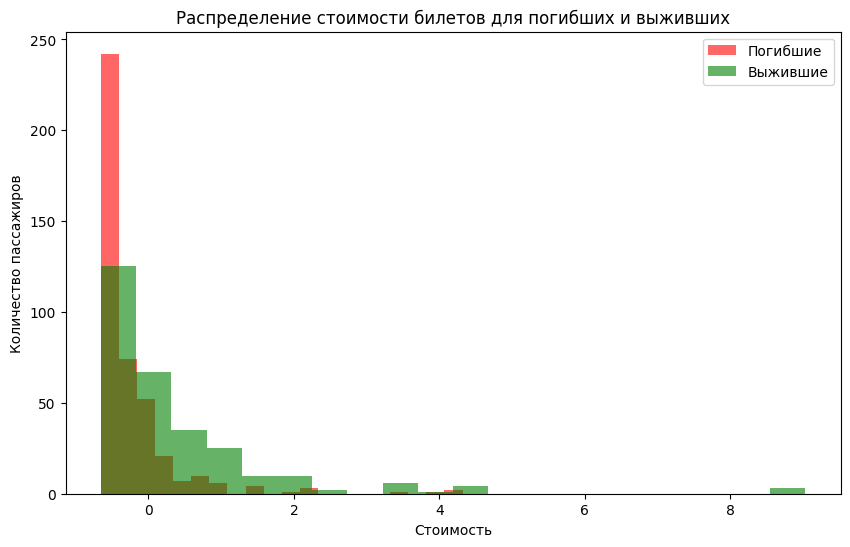

In [55]:
fare_dead = df[df['Survived'] == 0]['Fare']
fare_alive = df[df['Survived'] == 1]['Fare']

plt.figure(figsize=(10,6))
plt.hist(fare_dead, bins=20, alpha=0.6, label='Погибшие', color='red')
plt.hist(fare_alive, bins=20, alpha=0.6, label='Выжившие', color='green')

plt.xlabel('Стоимость')
plt.ylabel('Количество пассажиров')
plt.title('Распределение стоимости билетов для погибших и выживших')
plt.legend()
plt.show()

7. Сформируйте набор признаков (X). Сформируйте вектор целевых значений (y).

In [57]:
X = df[['Pclass','SibSp','Parch','female','male','Fare','Age']]
y = df['Survived']

## Предсказательная модель

8. Разделите набор данных на два, одни для обучения модели другой для проверки. Тестовый набор должен содержать 25 процентов данных.

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
    )

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (534, 7)
Размер тестовой выборки: (178, 7)


9. Выполните обучение модели.

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Проверка модели

10. Выведите мартицу ошибок

In [74]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm)
print("Матрица ошибок:")
cm_df

Матрица ошибок:


,0,1
0,86,13
1,23,56


11. Расчитайте accuracy

In [75]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 3))

Accuracy: 0.798


12. Сделайте вывод о полученном результате

Вывод: Модель показала достаточно хорошее качество: Accuracy = 0.798, то есть почти 80% пассажиров классифицированы правильно.

## Вопросы для защиты

1. Сформулируйте задачу классификации.

Задача классификации — это задача определения категориального класса объекта на основе его признаков

2. Перечислите типы классификации.

Типы классификации: бинарная, мультиклассовая, многометочная

3. В чем особенность несбалансированной классификации?

Несбалансированная классификация — когда частоты классов сильно различаются, из-за чего модель может плохо распознавать редкий класс.

4. В чем особенность мультиклассовой классификации?

Особенность мультиклассовой классификации в том, что каждый объект может принадлежать только одному из нескольких возможных классов. То есть задача не ограничена двумя категориями, а имеет три и более классов

5. В чем особенность бинарной классификации?

Бинарная классификация — задача, где объект принадлежит одному из двух классов

6. В чем особенность классификации по нескольким меткам?

Классификация по нескольким меткам — когда объект может одновременно принадлежать нескольким классам

7. Чем стратегия "Один против всех" отличается от стратегии "Один против одного"?

Стратегия "Один против всех" (One-vs-Rest) — для каждого класса строится классификатор против всех остальных;
стратегия "Один против одного" (One-vs-One) — строится классификатор для каждой пары классов.

8. Что такое матрица ошибок (несоответствий)?

Матрица ошибок — таблица, показывающая, сколько объектов каждого класса модель правильно и ошибочно классифицировала.

9. Как рассчитывается Accuracy?

Accuracy = Верные предсказания/Всего объектов

10. Объясните алгоритм классификации K-ближайших соседей.

Алгоритм K-ближайших соседей (KNN) — классифицирует объект по большинству классов его K ближайших соседей в пространстве признаков.